# REPSOL Model Training (70/15/15)

**ResNet50-02 — fixed data pipeline + anti-overfitting package**

Same recipe as EfficientNet-04 / MobileNetV3-02, applied to ResNet-50. ResNet50-01
trained on the broken data view (first 400/3156 pixel columns of full figure renders)
and overfit badly (25M params on 1,382 images). This run:

- trains on `Data/Spectrograms_224` (full spectrogram, no text/margins),
- freezes `conv1, bn1, layer1–3` — trains only `layer4` + head (~15M of 25.6M params).
  ResNet is the largest backbone of the set, so it gets the most aggressive freeze,
- SpecAugment, dropout 0.35, weight decay 1e-2, balanced weights + ×1.5 boost cls 1 & 7,
  label smoothing 0.1,
- checkpoints and early-stops on **val macro-F1**, ReduceLROnPlateau schedule.

Comparison targets: EfficientNet-04 = 83.2% test acc / 0.78 macro-F1,
MobileNetV3-02 = 86.5% / 0.83.

Note: ResNet-50 is ~4× the compute of EfficientNet-B0 — expect roughly 8–12 min/epoch on CPU.

## 0. Config

In [1]:
from pathlib import Path
import sys
import torch

# ===== Hyperparameters =====
BATCH_SIZE      = 16
EPOCHS          = 30
LEARNING_RATE   = 5e-4
WEIGHT_DECAY    = 1e-2
PATIENCE        = 6      # early stopping on val macro-F1
LABEL_SMOOTHING = 0.1
DROPOUT         = 0.35
FROZEN_PARTS    = ["conv1", "bn1", "layer1", "layer2", "layer3"]  # train layer4 + fc
MODEL_NAME      = "resnet50_02"

# ===== Paths =====
PROJECT_ROOT    = Path(r"D:\\Work\\Internships\\INMAR\\REPSOL")
SPECTROGRAM_DIR = PROJECT_ROOT / "Data" / "Spectrograms_224"
OUTPUT_DIR      = PROJECT_ROOT / "Models_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))


def next_run_path(model_name, suffix, ext, output_dir):
    prefix = f"{model_name}{suffix}"
    existing = [0]
    for p in output_dir.iterdir():
        if not p.is_file() or p.suffix != ext:
            continue
        stem = p.stem
        if stem.startswith(prefix + "_"):
            tail = stem[len(prefix) + 1:]
            if tail.isdigit():
                existing.append(int(tail))
    return output_dir / f"{prefix}_{max(existing)+1:02d}{ext}"


CHECKPOINT_PATH = next_run_path(MODEL_NAME, "_best", ".pth", OUTPUT_DIR)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("DEVICE         :", DEVICE)
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
print(f"LABEL_SMOOTHING={LABEL_SMOOTHING}  DROPOUT={DROPOUT}  FROZEN={FROZEN_PARTS}")

CHECKPOINT_PATH: D:\Work\Internships\INMAR\REPSOL\Models_output\resnet50_02_best_01.pth
DEVICE         : cpu
LR=0.0005  WD=0.01  EPOCHS=30  PATIENCE=6
LABEL_SMOOTHING=0.1  DROPOUT=0.35  FROZEN=['conv1', 'bn1', 'layer1', 'layer2', 'layer3']


## 1. Verify Data

In [2]:
def count_pt_files(root):
    counts = {}
    for split in ["train", "val", "test"]:
        split_dir = root / split
        counts[split] = sum(1 for _ in split_dir.rglob("*.norm.pt")) if split_dir.exists() else 0
    return counts

counts = count_pt_files(SPECTROGRAM_DIR)
print("Tensor files by split:", counts)
print("Total:", sum(counts.values()))

assert counts["train"] > 0, "No train .norm.pt files found — run src/preprocess/downsize_spectrograms.py first."
assert counts["val"]   > 0, "No val .norm.pt files found."
assert counts["test"]  > 0, "No test .norm.pt files found."

sample = next((SPECTROGRAM_DIR / "train").rglob("*.norm.pt"))
t = torch.load(sample)
print(f"Sample shape: {tuple(t.shape)}  mean={t.mean():.3f}  std={t.std():.3f}")
assert t.shape[-2:] == (224, 224), f"Expected 224x224 tensors, got {tuple(t.shape)}"

Tensor files by split: {'train': 1382, 'val': 296, 'test': 297}
Total: 1975
Sample shape: (3, 224, 224)  mean=-0.000  std=1.000


## 2. Training

In [3]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchaudio.transforms as TA
from sklearn.metrics import f1_score
from tqdm import tqdm

import src.ResNet.model as model_module
import src.dataloaders as dl_module

model_module = importlib.reload(model_module)
dl_module    = importlib.reload(dl_module)
ResNet50Spectrogram   = model_module.ResNet50Spectrogram
compute_class_weights = model_module.compute_class_weights
get_dataloaders       = dl_module.get_dataloaders


# ── SpecAugment: random frequency + time masks, TRAIN ONLY ──
class SpecAugment(nn.Module):
    def __init__(self, freq_mask=28, time_mask=28, n_freq=2, n_time=2):
        super().__init__()
        self.freq = nn.ModuleList([TA.FrequencyMasking(freq_mask) for _ in range(n_freq)])
        self.time = nn.ModuleList([TA.TimeMasking(time_mask) for _ in range(n_time)])
    def forward(self, x):
        for m in self.freq:
            x = m(x)
        for m in self.time:
            x = m(x)
        return x


# ── DataLoaders ──
train_loader, val_loader, test_loader = get_dataloaders(
    SPECTROGRAM_DIR, batch_size=BATCH_SIZE,
    num_workers=0, pin_memory=False, persistent_workers=False,
    cache_in_memory=True,
    train_transform=SpecAugment(),
    target_width=None,
)
NUM_CLASSES = len(train_loader.dataset.classes)
CLASS_NAMES = train_loader.dataset.classes
print("Classes:", NUM_CLASSES, "  Train batches:", len(train_loader))


# ── Model: freeze conv1/bn1/layer1-3, train layer4 + fc ──
model = ResNet50Spectrogram(num_classes=NUM_CLASSES, freeze_backbone=False).to(DEVICE)
for part in FROZEN_PARTS:
    for p in getattr(model.backbone, part).parameters():
        p.requires_grad = False
model.backbone.fc[0].p = DROPOUT   # head dropout, default 0.3

def set_frozen_bn_eval(m):
    """Keep BatchNorm running stats of frozen parts fixed during training."""
    for part in FROZEN_PARTS:
        getattr(m.backbone, part).eval()

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: {n_trainable/1e6:.2f}M trainable / {n_total/1e6:.2f}M total "
      f"({100*n_trainable/n_total:.0f}%)")


# ── Class weights: sklearn balanced + ×1.5 boost for the two worst classes ──
BOOST_CLASSES = {1: 1.5, 7: 1.5}

train_labels  = [label for (_, label) in train_loader.dataset.samples]
base_weights  = compute_class_weights(train_labels, num_classes=NUM_CLASSES).numpy()
final_weights = base_weights.copy()
for cls_idx, multiplier in BOOST_CLASSES.items():
    final_weights[cls_idx] *= multiplier
class_weights = torch.tensor(final_weights, dtype=torch.float).to(DEVICE)

print("\nClass weights:")
for i, (name, bw, fw) in enumerate(zip(CLASS_NAMES, base_weights, final_weights)):
    boost = f" x{BOOST_CLASSES[i]}" if i in BOOST_CLASSES else ""
    print(f"  [{i}] {name[:45]:45s}  balanced={bw:.3f}  final={fw:.3f}{boost}")


# ── Loss / optimiser / scheduler ──
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6)


# ── Checkpoint + history setup ──
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
HISTORY_PATH = CHECKPOINT_PATH.with_name(f"{CHECKPOINT_PATH.stem}_training_history.csv")
for p in (CHECKPOINT_PATH, HISTORY_PATH):
    if p.exists(): p.unlink()
with open(HISTORY_PATH, "w") as fh:
    fh.write("epoch,train_loss,val_loss,train_acc,val_acc,val_macro_f1,lr\n")
torch.save(model.state_dict(), CHECKPOINT_PATH)


# ── Training loop — checkpoint & early-stop on VAL MACRO-F1 (higher = better) ──
best_val_f1 = -1.0
no_improve = 0

for epoch in range(1, EPOCHS + 1):

    # --- train ---
    model.train()
    set_frozen_bn_eval(model)
    t_loss, t_correct, t_total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} Train", ncols=100, unit="batch")
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == y).sum().item()
        t_total   += y.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total

    # --- validate ---
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    all_preds, all_targets = [], []
    pbar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} Val  ", ncols=100, unit="batch")
    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            loss = criterion(out, y)
            v_loss    += loss.item()
            preds      = out.argmax(1)
            v_correct += (preds == y).sum().item()
            v_total   += y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(y.cpu().tolist())
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
    val_f1   = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
        f"| Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f} "
        f"| Val macro-F1: {val_f1:.4f} | LR: {current_lr:.2e}",
        flush=True,
    )

    with open(HISTORY_PATH, "a") as fh:
        fh.write(f"{epoch},{train_loss:.6f},{val_loss:.6f},{train_acc:.4f},{val_acc:.4f},{val_f1:.6f},{current_lr:.6f}\n")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  \u2713 Saved improved checkpoint \u2192 {CHECKPOINT_PATH.name}", flush=True)
    else:
        no_improve += 1
        print(f"  No improvement {no_improve}/{PATIENCE}", flush=True)
        if no_improve >= PATIENCE:
            print("  Early stopping.", flush=True)
            break

print("\nTraining finished.")
print(f"Best val macro-F1: {best_val_f1:.4f}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Classes: 8   Train batches: 87
Params: 14.98M trainable / 23.52M total (64%)

Class weights:
  [0] 0 ActividadBASE_NO pattern activity            balanced=1.093  final=1.093
  [1] 1 Pulses HAMMERING                             balanced=5.758  final=8.637 x1.5
  [2] 2 Marked cycles 3 segundos                     balanced=1.878  final=1.878
  [3] 3 Continuous activity & tone 3.15kHz_SPL ALTO  balanced=0.351  final=0.351
  [4] 4 Continuous activity & tone 3.15kHz_ SPL BAJ  balanced=0.971  final=0.971
  [5] 5 Blasts                                       balanced=3.387  final=3.387
  [6] 6 Machinery continuous activity                balanced=0.491  final=0.491
  [7] 7 Works_ sirens and knocks en altas frecuenci  balanced=5.957  final=8.935 x1.5


Epoch 01/30 Val  : 100%|█████████████████████████████████████████| 19/19 [00:31<00:00,  1.67s/batch]

Epoch 01/30 | Train Loss: 2.1107 | Val Loss: 2.5483 | Train Acc: 36.32 | Val Acc: 36.82 | Val macro-F1: 0.4402 | LR: 5.00e-04


  ✓ Saved improved checkpoint → resnet50_02_best_01.pth


Epoch 02/30 Val  : 100%|█████████████████████████████████████████| 19/19 [00:30<00:00,  1.62s/batch]

...

Epoch 18/30 | Train Loss: 1.2043 | Val Loss: 2.1331 | Train Acc: 89.80 | Val Acc: 77.70 | Val macro-F1: 0.7375 | LR: 1.25e-04
  No improvement 4/6



Epoch 19/30 Val  : 100%|█████████████████████████████████████████| 19/19 [00:29<00:00,  1.53s/batch]

Epoch 19/30 | Train Loss: 1.1886 | Val Loss: 2.1777 | Train Acc: 92.40 | Val Acc: 78.38 | Val macro-F1: 0.7423 | LR: 1.25e-04
  No improvement 5/6



Epoch 20/30 Val  : 100%|█████████████████████████████████████████| 19/19 [00:29<00:00,  1.54s/batch]

Epoch 20/30 | Train Loss: 1.1591 | Val Loss: 2.1230 | Train Acc: 92.76 | Val Acc: 78.04 | Val macro-F1: 0.7362 | LR: 6.25e-05
  No improvement 6/6
  Early stopping.

Training finished.
Best val macro-F1: 0.7667
Checkpoint: D:\Work\Internships\INMAR\REPSOL\Models_output\resnet50_02_best_01.pth


## 3. Evaluation

In [4]:
import importlib
import src.evaluate as eval_module

eval_module = importlib.reload(eval_module)
evaluate_model = eval_module.evaluate_model

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

val_metrics  = evaluate_model(model, val_loader,  DEVICE)
test_metrics = evaluate_model(model, test_loader, DEVICE)

print("Validation:")
print({k: round(val_metrics[k], 4) for k in ["accuracy", "precision", "recall", "f1"]})
print("\nTest:")
print({k: round(test_metrics[k], 4) for k in ["accuracy", "precision", "recall", "f1"]})

Validation:
{'accuracy': 0.8041, 'precision': 0.817, 'recall': 0.8041, 'f1': 0.8054}

Test:
{'accuracy': 0.8081, 'precision': 0.8422, 'recall': 0.8081, 'f1': 0.8207}


In [5]:
print("Test Classification Report:\n")
print(test_metrics["report"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

Test Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.73      0.80        33
           1       0.21      0.67      0.32         6
           2       0.79      0.75      0.77        20
           3       0.86      0.86      0.86       106
           4       0.76      0.72      0.74        39
           5       1.00      0.82      0.90        11
           6       0.92      0.86      0.88        76
           7       0.44      0.67      0.53         6

    accuracy                           0.81       297
   macro avg       0.73      0.76      0.73       297
weighted avg       0.84      0.81      0.82       297

Confusion Matrix:
[[24  1  0  1  4  0  3  0]
 [ 0  4  0  2  0  0  0  0]
 [ 0  0 15  2  3  0  0  0]
 [ 3  5  1 91  2  0  2  2]
 [ 0  1  3  7 28  0  0  0]
 [ 0  0  0  0  0  9  0  2]
 [ 0  8  0  2  0  0 65  1]
 [ 0  0  0  1  0  0  1  4]]


## 4. Learning Curves

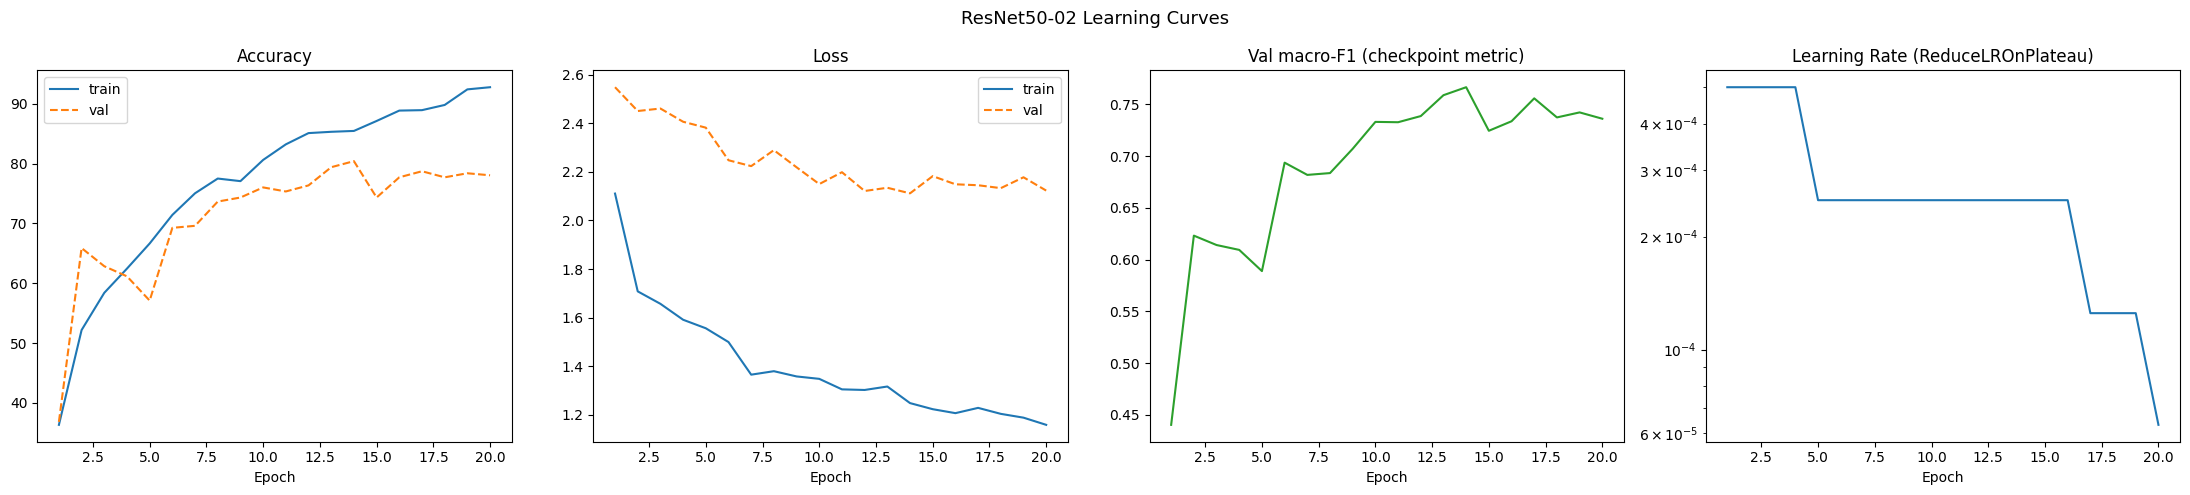

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(df["epoch"], df["train_acc"], label="train")
axes[0].plot(df["epoch"], df["val_acc"],   label="val", linestyle="--")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train_loss"], label="train")
axes[1].plot(df["epoch"], df["val_loss"],   label="val", linestyle="--")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["val_macro_f1"], color="tab:green")
axes[2].set_title("Val macro-F1 (checkpoint metric)"); axes[2].set_xlabel("Epoch")

axes[3].plot(df["epoch"], df["lr"])
axes[3].set_title("Learning Rate (ReduceLROnPlateau)"); axes[3].set_xlabel("Epoch")
axes[3].set_yscale("log")

fig.suptitle("ResNet50-02 Learning Curves", fontsize=13)
fig.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "evaluation" / "learning_curves_resnet50_02.png",
            dpi=150, bbox_inches="tight")
plt.show()